# Datos, evaluación y baselines — explicación paso a paso

**Proyecto Final Henry · Dynamo Consultoría & Data Solutions**

Este notebook explica, paso a paso y con los datos reales, la base del sistema de recomendación:

1. **Glosario** de los términos del proyecto.
2. **El panorama**: qué problema resolvemos y qué piezas construimos.
3. **Paso 1 — Datos** (`src/data/make_interactions.py`).
4. **Paso 2 — Evaluación** (`src/evaluation/evaluate.py`).
5. **Paso 3 — Baseline** (`src/models/popularity.py`).
6. **El flujo de trabajo en GitHub**.
7. **Preguntas frecuentes** con respuesta corta.

> Las salidas están guardadas, así que se puede leer sin ejecutarlo. Para re-ejecutarlo se necesitan los CSV de Olist en `data/raw/`.

## 1. Glosario

### Sistemas de recomendación

| Término | Qué significa | Ejemplo en nuestro proyecto |
|---|---|---|
| **Sistema de recomendación** | Programa que sugiere a cada usuario productos que probablemente le interesen | "Te podría interesar…" en una tienda en línea |
| **Interacción** | Cualquier registro de que un usuario tuvo contacto con un producto | Una compra: cliente X compró producto Y el día Z |
| **Señal implícita** | Interacción que muestra interés sin que el usuario lo diga (compras, clics) | Que alguien compre algo indica que le interesa |
| **Señal explícita** | El usuario declara su opinión directamente | La reseña de 1 a 5 estrellas (`review_score`) |
| **Top-K / top-N** | La lista de los K productos que el sistema recomienda | Top-10 = los 10 primeros |
| **Cold start** (arranque en frío) | No hay historial del usuario (o del producto), así que no se puede personalizar | Un cliente que entra por primera vez |
| **Sparsity** (dispersión) | Casi no hay datos por usuario: la mayoría de combinaciones usuario-producto están vacías | En Olist, solo 3 de cada 100,000 combinaciones tienen una compra |
| **Long tail** (cola larga) | Pocos productos concentran muchas ventas y la mayoría se vende muy poco | 60% de los productos tiene un solo comprador |
| **Baseline** (línea base) | Modelo muy simple que sirve de referencia: los modelos "inteligentes" deben superarlo | Recomendar lo más vendido |
| **Filtrado colaborativo** | Recomienda según usuarios parecidos ("a clientes parecidos les gustó…") | Necesita historial; falla en cold start |
| **Basado en contenido** | Recomienda productos parecidos por sus atributos (categoría, precio) | Si el cliente compró muebles, se le muestran muebles |
| **Item-to-item** | "Quienes compraron este producto también compraron…" | Modelo implementado en `src/models/item_based.py` (ver notebook 01) |

### Evaluación

| Término | Qué significa |
|---|---|
| **Train / test** | Datos para entrenar el modelo / datos guardados aparte para medir qué tan bien predice |
| **Split temporal** | Separar train y test por fecha: entrenas con el pasado y evalúas con el futuro |
| **Data leakage** (fuga de datos) | Que el modelo "vea" información del futuro al entrenar; da resultados falsamente buenos |
| **Ground truth** (verdad de referencia) | Lo que el usuario realmente compró en el test; contra eso se compara la recomendación |
| **Precision@K** | De los K productos recomendados, ¿qué fracción acertó? |
| **Recall@K** | De lo que el usuario realmente compró, ¿qué fracción encontré en mi top-K? |
| **HitRate@K** | ¿Acerté al menos uno? 1 = sí, 0 = no (promediado = % de usuarios con al menos un acierto) |
| **NDCG@K** | Como el acierto, pero da más puntos si el acierto está arriba en la lista |
| **Cobertura** | Qué % del catálogo llega a recomendarse alguna vez (detecta modelos que siempre recomiendan lo mismo) |
| **Segmento all / warm** | all = todos los usuarios del test; warm = solo los que ya tenían compras antes |

### Herramientas y trabajo en equipo

| Término | Qué significa |
|---|---|
| **Repositorio (repo)** | La carpeta del proyecto guardada en GitHub con todo su historial |
| **Rama (branch)** | Una copia paralela del proyecto donde trabajas sin afectar la versión principal |
| **`main`** | La rama principal, la versión "oficial" del proyecto |
| **Commit** | Un "guardado" con nombre: una foto de los cambios en un momento dado |
| **Push** | Subir los commits locales a GitHub |
| **Pull Request (PR)** | Solicitud para unir una rama a `main`; otro integrante la revisa antes |
| **Review / aprobación** | Que otro integrante revise el PR y lo apruebe |
| **Merge** | Unir la rama a `main` una vez aprobado el PR |
| **Branch protection** | Regla que impide subir directo a `main`: todo pasa por PR con aprobación |
| **`.gitignore`** | Lista de archivos que Git no sube (por ejemplo, los CSV pesados) |
| **Entorno virtual (`.venv`)** | Una instalación de Python aislada solo para este proyecto |
| **`requirements.txt`** | Lista de librerías que el proyecto necesita |
| **Pipeline** | Una secuencia de pasos automáticos: datos crudos → datos limpios → modelo → métricas |
| **Parquet** | Formato de archivo de datos más rápido y ligero que CSV, que conserva los tipos (fechas, números) |
| **Test unitario (`pytest`)** | Pequeño programa que verifica automáticamente que una función da el resultado esperado |

## 2. El panorama

**El problema:** Olist es un marketplace brasileño. Queremos recomendar a cada cliente productos que probablemente compre, para aumentar la recompra y la venta cruzada.

**Lo que construimos en el PR #1** es la base que necesita cualquier modelo:

```
 CSV crudos de Olist          Tabla de interacciones          Evaluación común          Baseline
 (9 archivos)          ──►    (quién compró qué y cuándo) ──►  (split + métricas)   ──►  (lo más popular)
 make_interactions.py          interactions.parquet            evaluate.py              popularity.py
```

Cada pieza responde una pregunta:

1. **¿Con qué datos trabajamos?** → tabla de interacciones limpia.
2. **¿Cómo sabemos si un modelo es bueno?** → protocolo de evaluación.
3. **¿Qué tan bueno tiene que ser?** → el baseline es el número a superar.

Ahora vamos pieza por pieza, ejecutando el código real.

In [1]:
# Preparación: localizar la raíz del repo para poder importar src/
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
AZUL = "#2a78d6"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.edgecolor": "#888"})
print("Raíz del repo:", ROOT)

Raíz del repo: /home/claude/dynamo-recsys-olist


## 3. Paso 1 — Datos (`make_interactions.py`)

### 3.1 Los datos crudos

Olist publica 9 tablas relacionadas. Para recomendar usamos 5:

| Tabla | Una fila es… | Columnas que usamos |
|---|---|---|
| `orders` | un pedido | `order_id`, `customer_id`, `order_status`, fecha de compra |
| `order_items` | un producto dentro de un pedido | `order_id`, `product_id`, `seller_id`, `price` |
| `customers` | un cliente *en un pedido* | `customer_id`, `customer_unique_id` |
| `products` | un producto | `product_id`, categoría |
| `order_reviews` | una reseña de un pedido | `order_id`, `review_score` |

In [2]:
from src.data.make_interactions import load_raw
raw = load_raw()
for nombre, df in raw.items():
    print(f"{nombre:12s} {len(df):>8,} filas  {df.shape[1]:>2} columnas")

orders         99,441 filas   8 columnas
items         112,650 filas   7 columnas
customers      99,441 filas   5 columnas
products       32,951 filas   9 columnas
reviews        99,224 filas   7 columnas
translation        71 filas   2 columnas


### 3.2 La trampa de `customer_id`

En Olist, **`customer_id` cambia en cada pedido**. El identificador real de la persona es **`customer_unique_id`**.

Si usáramos `customer_id`, cada compra parecería de un cliente nuevo y nunca veríamos a nadie volver a comprar. Mira un cliente real con varios pedidos:

In [3]:
cust = raw["customers"]
ord_ = raw["orders"].merge(cust, on="customer_id")
pedidos_por_persona = ord_.groupby("customer_unique_id")["order_id"].nunique()
ejemplo = pedidos_por_persona[pedidos_por_persona == 3].index[0]

ord_.loc[ord_["customer_unique_id"] == ejemplo,
         ["customer_unique_id", "customer_id", "order_id", "order_purchase_timestamp"]]

,customer_unique_id,customer_id,order_id,order_purchase_timestamp
335,02e9109b7e0a985108b43e573b6afb23,1ae196062dab95e434e781a5319f0ab9,a7076e7aba13de8b66d95a55811290ed,2018-05-14 11:04:55
89559,02e9109b7e0a985108b43e573b6afb23,14676dd9c40ad83f2a980ac36077cdb9,d85c2deca369a3930811855341fb3d11,2017-11-23 16:19:10
92416,02e9109b7e0a985108b43e573b6afb23,76525f0c94f889d91e4335fae56eaaaf,eb7df5ec433a5660c84c3a2e1bce192d,2018-05-13 23:53:10


**Lectura:** es la misma persona (`customer_unique_id` igual) con 3 `customer_id` distintos, uno por pedido. Por eso nuestro "usuario" es `customer_unique_id`.

### 3.3 Decisiones de limpieza

**a) Solo pedidos válidos.** Quitamos `canceled`, `unavailable` y `created`, porque no representan una compra real.

In [4]:
raw["orders"]["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

**b) Reseñas duplicadas.** Algunos pedidos tienen más de una reseña; nos quedamos con la más reciente (la opinión final del cliente).

**c) Ítems repetidos.** Si alguien compró 3 unidades del mismo producto en un pedido, `order_items` trae 3 filas. Las juntamos en 1 fila con `quantity = 3`, porque para recomendar importa *qué* compró, no cuántas unidades.

**d) Categorías.** Se traducen del portugués al inglés; los productos sin categoría quedan como `unknown` en lugar de borrarse (sí se vendieron).

Ahora ejecutamos el pipeline completo:

In [5]:
from src.data.make_interactions import build_interactions, summarize
inter, log = build_interactions(raw)
print("== Limpieza ==")
for k, v in log.items():
    print(f"  {k}: {v}")
inter.head()

== Limpieza ==
  pedidos_totales: 99441
  pedidos_validos: 98202
  pedidos_con_varias_reseñas: 551
  productos_sin_categoria: 610
  interacciones: 101953
  reseña_faltante_%: 0.77


,order_id,customer_unique_id,product_id,seller_id,purchase_ts,price,freight_value,quantity,review_score,category
0,2e7a8482f6fb09756ca50c10d7bfc047,b7d76e111c89f7ebf14761390f0f7d17,c1488892604e4ba5cff5b4eb4d595400,1554a68530182680ad5c8b042c3ab563,2016-09-04 21:15:19,39.99,31.67,1,1.0,furniture_decor
1,2e7a8482f6fb09756ca50c10d7bfc047,b7d76e111c89f7ebf14761390f0f7d17,f293394c72c9b5fafd7023301fc21fc2,1554a68530182680ad5c8b042c3ab563,2016-09-04 21:15:19,32.90,31.67,1,1.0,furniture_decor
2,bfbd0f9bdef84302105ad712db648a6c,830d5b7aaa3b6f1e9ad63703bec97d23,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-15 12:16:38,44.99,2.83,3,1.0,health_beauty
3,3b697a20d9e427646d92567910af6d57,32ea3bdedab835c3aa6cb68ce66565ef,3ae08df6bcbfe23586dd431c40bddbb7,522620dcb18a6b31cd7bdf73665113a9,2016-10-03 09:44:50,29.90,15.56,1,4.0,watches_gifts
4,be5bc2f0da14d8071e2d45451ad119d9,2f64e403852e6893ae37485d5fcacdaf,fd7fd78fd3cbc1b0a6370a7909c0a629,f09b760d23495ac9a7e00d29b769007c,2016-10-03 16:56:50,21.90,17.19,1,4.0,sports_leisure


**Cómo leer la tabla de interacciones:** cada fila dice *"el cliente X compró el producto Y (categoría Z, precio P) en tal fecha y le puso tal calificación al pedido"*. Es la materia prima de todos los modelos.

### 3.4 Lo que descubrimos: sparsity, long tail y cold start

In [6]:
for k, v in summarize(inter).items():
    print(f"  {k}: {v}")

  usuarios: 94983
  productos: 32729
  categorias: 74
  rango_fechas: 2016-09-04 a 2018-09-03
  usuarios_que_recompran_%: 3.04
  productos_con_1_comprador_%: 59.5
  densidad_matriz_%: 0.00327


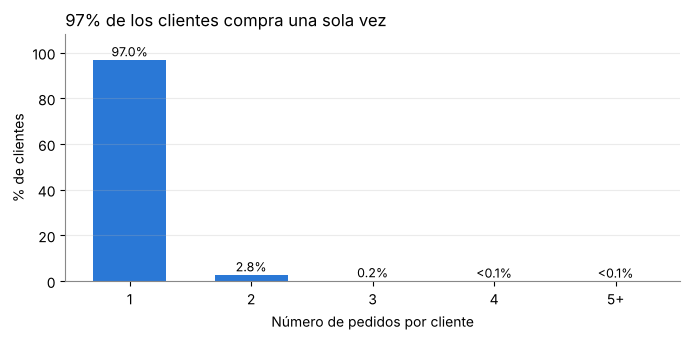

In [7]:
pedidos = inter.groupby("customer_unique_id")["order_id"].nunique().clip(upper=5)
dist = pedidos.value_counts().sort_index()
etiquetas = [str(i) if i < 5 else "5+" for i in dist.index]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(etiquetas, dist.values / dist.sum() * 100, color=AZUL, width=0.6)
for x, v in zip(etiquetas, dist.values / dist.sum() * 100):
    ax.text(x, v + 1.5, f"{v:.1f}%" if v >= 0.1 else "<0.1%", ha="center", fontsize=9)
ax.grid(axis="x", visible=False)
ax.set_ylim(0, 108)
ax.set_xlabel("Número de pedidos por cliente")
ax.set_ylabel("% de clientes")
ax.set_title("97% de los clientes compra una sola vez", loc="left")
plt.tight_layout(); plt.show()

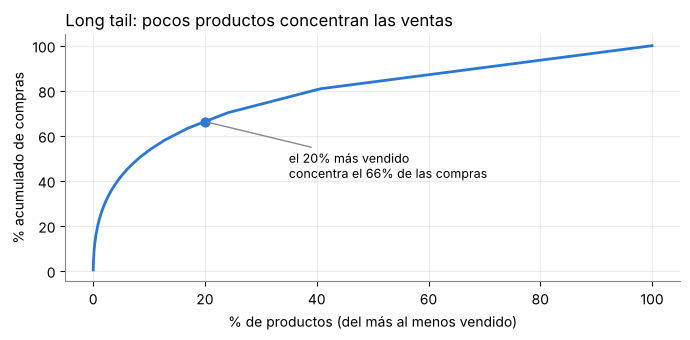

In [8]:
compradores = inter.groupby("product_id")["customer_unique_id"].nunique().sort_values(ascending=False)
acum = compradores.cumsum() / compradores.sum() * 100
pct_productos = (pd.RangeIndex(1, len(acum) + 1) / len(acum)) * 100

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(pct_productos, acum.values, color=AZUL, lw=2)
y20 = acum.values[int(len(acum) * 0.2) - 1]
ax.scatter([20], [y20], color=AZUL, s=40, zorder=3)
ax.annotate(f"el 20% más vendido\nconcentra el {y20:.0f}% de las compras", (20, y20),
            xytext=(35, y20 - 25), fontsize=9, arrowprops=dict(arrowstyle="-", color="#888"))
ax.set_xlabel("% de productos (del más al menos vendido)")
ax.set_ylabel("% acumulado de compras")
ax.set_title("Long tail: pocos productos concentran las ventas", loc="left")
plt.tight_layout(); plt.show()

**Qué significa para el proyecto:**

- **Sparsity:** si hiciéramos una tabla con todos los usuarios en filas y todos los productos en columnas, solo ~3 de cada 100,000 celdas tendrían una compra.
- **Cold start:** como el 97% compra una sola vez, casi nunca tenemos historial para personalizar.
- **Long tail:** la mayoría de productos casi no se vende, así que es difícil recomendarlos.

Por eso el filtrado colaborativo clásico funciona mal aquí, y por eso hace falta un baseline fuerte y una evaluación diseñada para este caso.

## 4. Paso 2 — Evaluación (`evaluate.py`)

Antes de construir modelos hay que definir **cómo se mide** si son buenos. Si cada quien midiera distinto, no podríamos comparar. Por eso todo el equipo usa este mismo archivo.

### 4.1 Split temporal

- **Train:** compras antes del **2018-06-01**. Con esto "aprende" el modelo.
- **Test:** compras del **2018-06-01 al 2018-09-01**. Con esto lo examinamos.

**¿Por qué por fecha y no al azar?** Porque en la vida real el sistema usa el pasado para predecir el futuro. Si mezcláramos al azar, el modelo entrenaría con compras "del futuro" (*data leakage*) y los resultados serían engañosamente buenos.

In [9]:
from src.evaluation.evaluate import temporal_split, ground_truth
train, test = temporal_split(inter)
print(f"Train: {len(train):,} interacciones  ({train.purchase_ts.min():%Y-%m-%d} a {train.purchase_ts.max():%Y-%m-%d})")
print(f"Test:  {len(test):,} interacciones  ({test.purchase_ts.min():%Y-%m-%d} a {test.purchase_ts.max():%Y-%m-%d})")

Train: 82,414 interacciones  (2016-09-04 a 2018-05-31)
Test:  19,538 interacciones  (2018-06-01 a 2018-08-29)


### 4.2 Ground truth: qué cuenta como acierto

Para cada usuario del test, los **productos relevantes** son los que compró en ese periodo **y no había comprado antes** (recomendar algo que ya tiene no aporta).

In [10]:
truth = ground_truth(train, test)
usuarios_warm = set(train["customer_unique_id"])
warm = [u for u in truth if u in usuarios_warm]
print(f"Usuarios en test con compras nuevas: {len(truth):,}")
print(f"  de ellos, con historial previo (warm): {len(warm):,}  ({len(warm)/len(truth):.1%})")
print(f"  sin historial (cold start):            {len(truth)-len(warm):,}")

Usuarios en test con compras nuevas: 18,533
  de ellos, con historial previo (warm): 387  (2.1%)
  sin historial (cold start):            18,146


**Lectura:** de 18,533 usuarios a evaluar, solo 387 (~2%) ya habían comprado antes. Por eso reportamos dos segmentos:

- **all:** todos. Mide qué tan bien funciona el sistema en general (dominado por cold start).
- **warm:** solo los que tienen historial. Es donde un modelo puede personalizar de verdad.

### 4.3 Las métricas con un ejemplo de juguete

Supongamos que recomendamos 5 productos `[A, B, C, D, E]` y el usuario en realidad compró `{B, Z}`.

In [11]:
from src.evaluation.evaluate import precision_at_k, recall_at_k, hit_rate_at_k, ndcg_at_k
recs = ["A", "B", "C", "D", "E"]
compro = {"B", "Z"}
K = 5
print(f"Precision@{K} = {precision_at_k(recs, compro, K):.2f}   -> 1 acierto de 5 recomendados")
print(f"Recall@{K}    = {recall_at_k(recs, compro, K):.2f}   -> encontré 1 de los 2 que compró")
print(f"HitRate@{K}   = {hit_rate_at_k(recs, compro, K):.0f}      -> sí acerté al menos uno")
print(f"NDCG@{K}      = {ndcg_at_k(recs, compro, K):.2f}   -> el acierto está en la posición 2, no en la 1")
print(f"NDCG si B estuviera primero = {ndcg_at_k(['B','A','C','D','E'], compro, K):.2f}")

Precision@5 = 0.20   -> 1 acierto de 5 recomendados
Recall@5    = 0.50   -> encontré 1 de los 2 que compró
HitRate@5   = 1      -> sí acerté al menos uno
NDCG@5      = 0.39   -> el acierto está en la posición 2, no en la 1
NDCG si B estuviera primero = 0.61


- **Precision** mira *mi lista*: ¿cuánto de lo que recomendé sirvió?
- **Recall** mira *al usuario*: ¿cuánto de lo que quería encontré?
- **HitRate** es la más fácil de explicar a negocio: "% de clientes a los que les acertamos al menos una".
- **NDCG** premia poner lo bueno arriba, como en un buscador.
- **Cobertura** (se calcula sobre todos los usuarios): qué % del catálogo llega a recomendarse.

Estas métricas se calculan para cada usuario y luego se **promedian**.

### 4.4 El contrato común

Cada modelo del equipo debe tener dos funciones:

- `fit(train)`: aprende a partir de los datos de entrenamiento.
- `recommend(usuario, k)`: devuelve una lista de k productos.

Con eso, cualquier modelo entra a `evaluate()` y sale en la misma tabla. Es lo que permite comparar el trabajo de distintas personas.

## 5. Paso 3 — Baselines (`popularity.py`)

Un **baseline** es el modelo más simple razonable. Si un modelo complejo no le gana, no vale la pena usarlo.

| Baseline | Cómo recomienda |
|---|---|
| `pop_global` | Los productos con más compradores distintos. Igual para todos |
| `pop_global_rating` | Lo mismo, ajustado por la calificación promedio con un **promedio bayesiano** |
| `pop_categoria` | Si el usuario tiene historial: lo más popular de sus categorías favoritas. Si no: popularidad global |

**Promedio bayesiano**, en simple: un producto con 2 reseñas de 5 estrellas no debería ganarle a uno con 300 reseñas de 4.5. Con pocas reseñas, el promedio se "jala" hacia la media general hasta tener más evidencia.

Todos excluyen lo que el usuario ya compró.

In [12]:
from src.models.popularity import PopularityRecommender, CategoryPopularityRecommender
pop = PopularityRecommender().fit(train)
cat_de = train.drop_duplicates("product_id").set_index("product_id")["category"]

top = pd.DataFrame({"product_id": pop.top_[:10]})
top["categoria"] = top["product_id"].map(cat_de)
top["compradores"] = top["product_id"].map(pop.ranking_)
print("Top-10 global (lo que recibe cualquier usuario nuevo):")
top

Top-10 global (lo que recibe cualquier usuario nuevo):


,product_id,categoria,compradores
0,99a4788cb24856965c36a24e339b6058,bed_bath_table,430.0
1,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,424.0
2,422879e10f46682990de24d770e7f83d,garden_tools,333.0
3,389d119b48cf3043d311335e499d9c6b,garden_tools,284.0
4,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,282.0
5,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,277.0
6,368c6c730842d78016ad823897a372db,garden_tools,269.0
7,53759a2ecddad2bb87a079a1f1519f73,garden_tools,265.0
8,154e7e31ebfa092203795c972e5804a6,health_beauty,260.0
9,2b4609f8948be18874494203496bc318,health_beauty,226.0


In [13]:
pop_cat = CategoryPopularityRecommender(rating_weight=True).fit(train)
u = warm[0]
historial = train.loc[train.customer_unique_id == u, ["product_id", "category", "purchase_ts"]]
print("Historial del usuario warm (lo que compró antes):")
display(historial)

recs_u = pop_cat.recommend(u, 5)
print("Recomendaciones de pop_categoria:")
display(pd.DataFrame({"product_id": recs_u, "categoria": [cat_de.get(p) for p in recs_u]}))

print("Lo que realmente compró en el test:")
display(pd.DataFrame({"product_id": list(truth[u]), "categoria": [cat_de.get(p, "(producto nuevo)") for p in truth[u]]}))

Historial del usuario warm (lo que compró antes):


,product_id,category,purchase_ts
81372,a42d9c825894f96fc6ed02610891454d,sports_leisure,2018-05-23 20:14:21


Recomendaciones de pop_categoria:


,product_id,categoria
0,e44f675b60b3a3a2453ec36421e06f0f,sports_leisure
1,c6336fa91fbd87c359e44f5dca5a90ed,sports_leisure
2,11875b30b49585209e608f40e8082e65,sports_leisure
3,d3c044bd42d84a79e3b0c42662806a48,sports_leisure
4,44a34214a57dc373dcd80f54c919d006,sports_leisure


Lo que realmente compró en el test:


,product_id,categoria
0,f89cd865cac300a9bf1320dd8f0fa223,electronics


**Lectura:** para un usuario con historial, `pop_categoria` recomienda productos de las categorías que ya compró (aquí, deportes), en vez del top global genérico. Así "personaliza un poco" sin un modelo complejo.

En este ejemplo **no acertó**: el usuario después compró electrónica. Es un caso típico y explica por qué las métricas son bajas: aunque sepamos qué le gustó antes, la siguiente compra puede ser de algo totalmente distinto.

### 5.1 Resultados

In [14]:
from src.evaluation.evaluate import evaluate
modelos = {
    "pop_global": PopularityRecommender(),
    "pop_global_rating": PopularityRecommender(rating_weight=True),
    "pop_categoria": CategoryPopularityRecommender(rating_weight=True),
}
res = pd.concat([evaluate(m.fit(train), train, test, name=n) for n, m in modelos.items()])
tabla = (res[res.k == 10]
         .pivot(index="model", columns="segment", values=["hit_rate@k", "precision@k", "recall@k", "coverage"])
         .round(4))
tabla

hit_rate@k         precision@k         recall@k         coverage        
segment                  all    warm         all    warm      all    warm      all    warm
model                                                                                     
pop_categoria         0.0121  0.0207      0.0012  0.0021   0.0117  0.0181   0.0167  0.0167
pop_global            0.0119  0.0103      0.0012  0.0010   0.0115  0.0073   0.0004  0.0004
pop_global_rating     0.0119  0.0103      0.0012  0.0010   0.0115  0.0073   0.0004  0.0004

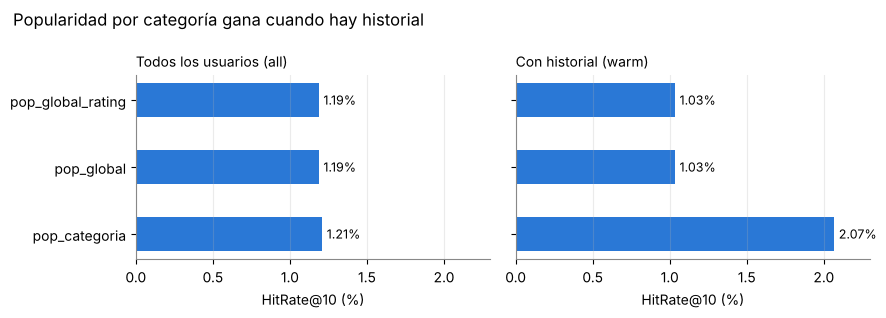

In [15]:
k10 = res[res.k == 10].set_index(["model", "segment"])["hit_rate@k"].unstack()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True, sharex=True)
for ax, seg, titulo in [(axes[0], "all", "Todos los usuarios (all)"), (axes[1], "warm", "Con historial (warm)")]:
    vals = k10[seg] * 100
    ax.barh(vals.index, vals.values, color=AZUL, height=0.5)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.03, i, f"{v:.2f}%", va="center", fontsize=9)
    ax.set_title(titulo, loc="left", fontsize=10)
    ax.set_xlabel("HitRate@10 (%)")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 2.3)
fig.suptitle("Popularidad por categoría gana cuando hay historial", x=0.02, ha="left")
plt.tight_layout(); plt.show()

**Cómo leer los resultados:**

- **HitRate@10 ≈ 1.2% (all):** a 1 de cada ~83 usuarios le acertamos al menos un producto en el top-10. Parece poco, pero hay ~32,000 productos y casi todos los usuarios son nuevos.
- **En all los tres empatan**, porque a los usuarios nuevos todos les dan el mismo top global.
- **En warm, `pop_categoria` duplica el acierto (1.0% → 2.1%):** saber qué categoría le gusta al usuario sí ayuda.
- **Cobertura:** los globales recomiendan siempre los mismos ~10 productos (0.04% del catálogo); `pop_categoria` reparte más (1.7%).
- **Precision@10 está limitada:** cada usuario compra en promedio ~1 producto en el test, así que el máximo posible es ~0.1.

**Resumen:** el número a superar es **HitRate@10 ≈ 1.2%** en general y **≈ 2.1%** en usuarios con historial.

> Nota: los empates de popularidad se rompen por `product_id`, así que estos números son idénticos en cualquier computadora.

## 6. El flujo de trabajo en GitHub

Cómo está organizado el trabajo en equipo y por qué:

1. **Repo en la cuenta del equipo** (`DynamoConsultoriaDataSolutions/dynamo-recsys-olist`): el proyecto es del equipo, no de una persona.
2. **Colaboradores con cuenta personal:** cada commit queda a nombre de quien lo hizo, así se ve el aporte individual.
3. **`main` protegida:** nadie puede subir cambios directo; todo pasa por Pull Request con al menos 1 aprobación.
4. **Flujo de trabajo:** `clone` (bajar el repo) → `checkout -b` (crear una rama) → cambios → `add` + `commit` (guardar) → `push` (subir) → abrir **PR** → un compañero lo **aprueba** → **merge** a `main`.
5. **`.gitignore`:** los CSV no se suben (son pesados); cada quien los pone en `data/raw/`.
6. **Pruebas automáticas (`pytest`):** verifican que las métricas, el split y los modelos funcionan bien.

Estructura del repo (inspirada en *Cookiecutter Data Science*, simplificada):

```
data/raw/         CSV originales (no se suben)
data/processed/   interactions.parquet (no se sube)
notebooks/        análisis y explicaciones (como este)
src/data/         limpieza y construcción de la tabla de interacciones
src/evaluation/   protocolo de evaluación común
src/models/       baselines, modelo item-to-item y comparación
reports/          resultados y figuras
tests/            pruebas automáticas
```

## 7. Preguntas frecuentes

| Pregunta | Respuesta corta |
|---|---|
| ¿Por qué `customer_unique_id` y no `customer_id`? | `customer_id` cambia en cada pedido; con él nadie parecería volver a comprar (3.2) |
| ¿Por qué el cold start es tan fuerte en Olist? | El 97% de los clientes compra una sola vez y el 60% de los productos tiene un solo comprador (3.4) |
| ¿Por qué un split temporal y no aleatorio? | Simula el uso real (pasado → futuro) y evita *data leakage* (4.1) |
| ¿Precision@K vs Recall@K? | Precision mira la lista recomendada; Recall mira lo que el cliente compró (4.3) |
| ¿Para qué sirve un baseline? | Es la referencia mínima: un modelo más complejo debe superarlo (5) |
| ¿Por qué `pop_categoria` gana en warm pero empata en all? | Los clientes nuevos no tienen categorías favoritas, así que reciben el mismo top global (5.1) |
| ¿Para qué proteger `main`? | Todo cambio entra por Pull Request revisado por otro integrante (6) |

**Siguiente paso:** el modelo item-to-item híbrido y su comparación contra estos baselines están en `01_explicacion_item_to_item.ipynb`.